In [92]:
!pip install matplotlib networkx folium

In [93]:
import os
import sys
import time
import random
import tracemalloc
import heapq
from collections import deque
from typing import List, Tuple, Dict, Callable, Any
from pathlib import Path
from IPython.display import display

import networkx as nx
import folium
import matplotlib.pyplot as plt

%matplotlib inline

In [94]:
CENARIOS = {
    "caatinga": {
        "nome_cenario": "Seca Extrema na Caatinga (Rota da Água)",
        "fontes": "ANA (Hidrologia), INMET (Seca Histórica), IBGE, DNIT",
        "municipios": {
            2611101: (2611101, 'Petrolina (Hub)', 1.2, 5000.0, 354317),
            2608750: (2608750, 'Lagoa Grande', 4.5, 2000.0, 25849),
            2603009: (2603009, 'Cabrobó', 5.8, 2500.0, 34503),
            2612208: (2612208, 'Salgueiro', 8.2, 4000.0, 61249),
            2610400: (2610400, 'Ouricuri', 9.8, 4500.0, 70000)
        },
        "grafo": {
            2611101: [(2608750, 20.0), (2603009, 50.0)],
            2608750: [(2611101, 20.0), (2610400, 200.0)],
            2603009: [(2611101, 50.0), (2612208, 40.0)],
            2612208: [(2603009, 40.0), (2610400, 30.0)],
            2610400: [(2608750, 200.0), (2612208, 30.0)]
        },
        "coords": {
            2611101: (-9.3833, -40.5000),
            2608750: (-8.9950, -40.2700),
            2603009: (-8.5133, -39.3100),
            2612208: (-8.0744, -39.1194),
            2610400: (-7.8825, -40.0811)
        }
    },
    
    "amazonia": {
        "nome_cenario": "Rotas de Fiscalização (DETER/Amazônia)",
        "fontes": "INPE (PRODES/DETER), IBGE, DNIT (Rodovias/Fluvial)",
        "municipios": {
            1302603: (1302603, 'Manaus (Base Central)', 1.5, 0.0, 2063689),
            1500602: (1500602, 'Altamira', 8.9, 3500.0, 126279),
            1507300: (1507300, 'São Félix do Xingu', 9.5, 4200.0, 65418),
            1100205: (1100205, 'Porto Velho', 6.2, 2800.0, 460413),
            1505064: (1505064, 'Novo Progresso', 7.8, 3100.0, 34224)
        },
        "grafo": {
            1302603: [(1500602, 45.0), (1100205, 30.0)],
            1500602: [(1302603, 45.0), (1505064, 15.0)],
            1100205: [(1302603, 30.0), (1507300, 60.0)],
            1507300: [(1100205, 60.0), (1505064, 25.0)],
            1505064: [(1500602, 15.0), (1507300, 25.0)]
        },
        "coords": {
            1302603: (-3.1190, -60.0217),
            1500602: (-3.2033, -52.2064),
            1507300: (-6.6444, -51.9950),
            1100205: (-8.7619, -63.9039),
            1505064: (-7.1483, -55.4200)
        }
    }
}

def obter_cenario(nome_cenario: str) -> Dict:
    nome_cenario = nome_cenario.lower()
    if nome_cenario not in CENARIOS:
        raise ValueError(f"Cenário '{nome_cenario}' não encontrado. Escolha 'caatinga' ou 'amazonia'.")
    return CENARIOS[nome_cenario]

In [95]:
class NodoBST:
    def __init__(self, dados_municipio: Tuple[int, str, float, float, int]):
        self.dados = dados_municipio
        self.risco = dados_municipio[2]
        self.esquerda = None
        self.direita = None

class ArvoreRiscoBST:
    def __init__(self):
        self.raiz = None

    def inserir(self, dados: Tuple[int, str, float, float, int]):
        if self.raiz is None:
            self.raiz = NodoBST(dados)
        else:
            self._inserir_recursivo(self.raiz, dados)

    def _inserir_recursivo(self, atual: NodoBST, dados: Tuple):
        if dados[2] < atual.risco:
            if atual.esquerda is None:
                atual.esquerda = NodoBST(dados)
            else:
                self._inserir_recursivo(atual.esquerda, dados)
        else:
            if atual.direita is None:
                atual.direita = NodoBST(dados)
            else:
                self._inserir_recursivo(atual.direita, dados)

    def buscar(self, r_min: float, r_max: float) -> List[Tuple]:
        resultados = []
        self._buscar_intervalo(self.raiz, r_min, r_max, resultados)
        return resultados

    def _buscar_intervalo(self, atual: NodoBST, r_min: float, r_max: float, resultados: List[Tuple]):
        if atual is None:
            return
        if atual.risco > r_min:
            self._buscar_intervalo(atual.esquerda, r_min, r_max, resultados)
        if r_min <= atual.risco <= r_max:
            resultados.append(atual.dados)
        if atual.risco < r_max:
            self._buscar_intervalo(atual.direita, r_min, r_max, resultados)

    def percurso_in_order(self) -> List[Tuple]:
        resultados = []
        self._in_order(self.raiz, resultados)
        return resultados

    def _in_order(self, atual: NodoBST, resultados: List[Tuple]):
        if atual:
            self._in_order(atual.esquerda, resultados)
            resultados.append(atual.dados)
            self._in_order(atual.direita, resultados)

class SistemaRoteamento:
    def __init__(self, nome_cenario: str):
        self.dados_brutos = obter_cenario(nome_cenario)
        self.nome = self.dados_brutos["nome_cenario"]
        self.fontes = self.dados_brutos["fontes"]
        
        self.municipios = self.dados_brutos["municipios"]
        self.grafo = self.dados_brutos["grafo"]
        self.coords = self.dados_brutos["coords"]
        
        self.arvore_risco = ArvoreRiscoBST()
        for dados_mun in self.municipios.values():
            self.arvore_risco.inserir(dados_mun)

In [96]:
class NodoBST:
    def __init__(self, dados_municipio: Tuple[int, str, float, float, int]):
        self.dados = dados_municipio
        self.risco = dados_municipio[2]
        self.esquerda = None
        self.direita = None

class ArvoreRiscoBST:
    def __init__(self):
        self.raiz = None

    def inserir(self, dados: Tuple[int, str, float, float, int]):
        if self.raiz is None:
            self.raiz = NodoBST(dados)
        else:
            self._inserir_recursivo(self.raiz, dados)

    def _inserir_recursivo(self, atual: NodoBST, dados: Tuple):
        if dados[2] < atual.risco:
            if atual.esquerda is None:
                atual.esquerda = NodoBST(dados)
            else:
                self._inserir_recursivo(atual.esquerda, dados)
        else:
            if atual.direita is None:
                atual.direita = NodoBST(dados)
            else:
                self._inserir_recursivo(atual.direita, dados)

    def buscar(self, r_min: float, r_max: float) -> List[Tuple]:
        resultados = []
        self._buscar_intervalo(self.raiz, r_min, r_max, resultados)
        return resultados

    def _buscar_intervalo(self, atual: NodoBST, r_min: float, r_max: float, resultados: List[Tuple]):
        if atual is None:
            return
        if atual.risco > r_min:
            self._buscar_intervalo(atual.esquerda, r_min, r_max, resultados)
        if r_min <= atual.risco <= r_max:
            resultados.append(atual.dados)
        if atual.risco < r_max:
            self._buscar_intervalo(atual.direita, r_min, r_max, resultados)

    def percurso_in_order(self) -> List[Tuple]:
        resultados = []
        self._in_order(self.raiz, resultados)
        return resultados

    def _in_order(self, atual: NodoBST, resultados: List[Tuple]):
        if atual:
            self._in_order(atual.esquerda, resultados)
            resultados.append(atual.dados)
            self._in_order(atual.direita, resultados)

class SistemaRoteamento:
    def __init__(self, nome_cenario: str):
        self.dados_brutos = obter_cenario(nome_cenario)
        self.nome = self.dados_brutos["nome_cenario"]
        self.fontes = self.dados_brutos["fontes"]
        
        self.municipios = self.dados_brutos["municipios"]
        self.grafo = self.dados_brutos["grafo"]
        self.coords = self.dados_brutos["coords"]
        
        self.arvore_risco = ArvoreRiscoBST()
        for dados_mun in self.municipios.values():
            self.arvore_risco.inserir(dados_mun)

In [97]:
def algoritmo_forca_bruta(grafo: dict, origem: int, destino: int, visitados: set = None, caminho_atual: list = None) -> Tuple[float, List[int]]:
    if visitados is None: visitados = set()
    if caminho_atual is None: caminho_atual = []

    visitados.add(origem)
    caminho_atual.append(origem)

    if origem == destino:
        return 0.0, list(caminho_atual)

    menor_custo = float('inf')
    melhor_caminho = []

    for vizinho, distancia in grafo.get(origem, []):
        if vizinho not in visitados:
            custo_restante, caminho_restante = algoritmo_forca_bruta(
                grafo, vizinho, destino, visitados.copy(), list(caminho_atual)
            )
            if custo_restante != float('inf'):
                custo_total = distancia + custo_restante
                if custo_total < menor_custo:
                    menor_custo = custo_total
                    melhor_caminho = caminho_restante

    return menor_custo, melhor_caminho


def algoritmo_guloso_dijkstra(grafo: Dict[int, List[Tuple[int, float]]], origem: int, destino: int) -> Tuple[float, List[int]]:
    custos_acumulados = {nodo: float('inf') for nodo in grafo}
    custos_acumulados[origem] = 0.0
    
    predecessores = {nodo: None for nodo in grafo}
    visitados = set()
    fronteira_heap = [(0.0, origem)]
    
    while fronteira_heap:
        custo_atual, atual = heapq.heappop(fronteira_heap)
        
        if atual in visitados:
            continue
            
        visitados.add(atual)
        
        if atual == destino:
            break
            
        for vizinho, peso_aresta in grafo.get(atual, []):
            if vizinho in visitados:
                continue
                
            novo_custo = custo_atual + peso_aresta
            
            if novo_custo < custos_acumulados[vizinho]:
                custos_acumulados[vizinho] = novo_custo
                predecessores[vizinho] = atual
                heapq.heappush(fronteira_heap, (novo_custo, vizinho))
                
    caminho_reconstruido = []
    passo = destino
    
    if custos_acumulados[destino] == float('inf'):
        return float('inf'), []
        
    while passo is not None:
        caminho_reconstruido.insert(0, passo)
        passo = predecessores[passo]
        
    return custos_acumulados[destino], caminho_reconstruido

In [98]:
operacoes_dijkstra = 0
operacoes_forca_bruta = 0

def gerar_grafo_aleatorio(n_vertices: int, probabilidade_aresta: float = 0.4) -> Dict[int, List[Tuple[int, float]]]:
    """Gera um grafo aleatório ponderado para testes de escalabilidade."""
    grafo_nx = nx.erdos_renyi_graph(n_vertices, probabilidade_aresta, seed=42, directed=False)
    if not nx.is_connected(grafo_nx):
        grafo_nx = nx.fast_gnp_random_graph(n_vertices, 0.8, seed=42)
        
    grafo_dict = {i: [] for i in range(n_vertices)}
    for u, v in grafo_nx.edges():
        peso = round(random.uniform(10.0, 100.0), 1)
        grafo_dict[u].append((v, peso))
        grafo_dict[v].append((u, peso))
    return grafo_dict

def plot_gap_otimalidade(func_forca_bruta, func_guloso_simples):
    """Gera o gráfico de diferença percentual entre a solução Ótima e a Gulosa Ingênua."""
    tamanhos_n = [5, 6, 7, 8, 9, 10, 11, 12]
    gaps = []
    
    for n in tamanhos_n:
        grafo = gerar_grafo_aleatorio(n)
        origem, destino = 0, n - 1
        
        custo_fb, _ = func_forca_bruta(grafo, origem, destino)
        custo_guloso, _ = func_guloso_simples(grafo, origem, destino)
        
        if custo_fb > 0 and custo_fb != float('inf') and custo_guloso != float('inf'):
            gap_percentual = ((custo_guloso - custo_fb) / custo_fb) * 100
            gaps.append(gap_percentual)
        else:
            gaps.append(0)
            
    plt.figure(figsize=(10, 6))
    plt.plot(tamanhos_n, gaps, marker='s', color='#e74c3c', linewidth=2)
    plt.title("Gap de Otimalidade: Força Bruta vs Guloso Simples", fontsize=14)
    plt.xlabel("Número de Vértices (N)", fontsize=12)
    plt.ylabel("Diferença Percentual do Custo (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig("gap_otimalidade.png", dpi=120)
    plt.close()

def run_benchmark_e_plotar(func_dijkstra: Callable, func_forca_bruta: Callable):
    """
    Executa a bateria de testes pedida na rubrica e plota o gráfico.
    Tamanhos: N = 5, 8, 10, 12, 20, 50, 100
    """
    tamanhos_n = [5, 8, 10, 12, 20, 50, 100]
    
    tempos_dijkstra = []
    tempos_fb = []
    
    print(f"{'N':<5} | {'Algoritmo':<15} | {'Tempo (ms)':<15} | {'Memória (MB)':<15} | {'Operações'}")
    print("-" * 75)
    
    for n in tamanhos_n:
        grafo = gerar_grafo_aleatorio(n)
        origem, destino = 0, n - 1
        
        # --- TESTE: DIJKSTRA (GULOSO) ---
        global operacoes_dijkstra
        operacoes_dijkstra = 0 
        
        tracemalloc.start()
        t0 = time.perf_counter()
        _ = func_dijkstra(grafo, origem, destino) # Executa
        t1 = time.perf_counter()
        mem_dijkstra = tracemalloc.get_traced_memory()[1] / (1024 * 1024) # MB
        tracemalloc.stop()
        
        tempo_ms_dijkstra = (t1 - t0) * 1000
        tempos_dijkstra.append(tempo_ms_dijkstra)
        
        print(f"{n:<5} | {'Dijkstra':<15} | {tempo_ms_dijkstra:<15.4f} | {mem_dijkstra:<15.6f} | {operacoes_dijkstra} relaxamentos")
        
        # --- TESTE: FORÇA BRUTA ---
        if n <= 12:
            global operacoes_forca_bruta
            operacoes_forca_bruta = 0
            
            tracemalloc.start()
            t0 = time.perf_counter()
            _ = func_forca_bruta(grafo, origem, destino) 
            t1 = time.perf_counter()
            mem_fb = tracemalloc.get_traced_memory()[1] / (1024 * 1024) 
            tracemalloc.stop()
            
            tempo_ms_fb = (t1 - t0) * 1000
            tempos_fb.append(tempo_ms_fb)
            print(f"{n:<5} | {'Força Bruta':<15} | {tempo_ms_fb:<15.4f} | {mem_fb:<15.6f} | {operacoes_forca_bruta} chamadas")
        else:
            tempos_fb.append(None) 
            print(f"{n:<5} | {'Força Bruta':<15} | {'TIMEOUT (Estouro)':<15} | {'-':<15} | > 10^6 chamadas")
            
    # --- GERAÇÃO DO GRÁFICO (Matplotlib) ---
    plt.figure(figsize=(10, 6))
    
    # Plota Dijkstra (N de 5 a 100)
    plt.plot(tamanhos_n, tempos_dijkstra, marker='o', color='blue', label='Dijkstra (O(E log V))', linewidth=2)
    
    # Plota Força Bruta (Somente até N=12)
    n_validos_fb = [n for n in tamanhos_n if n <= 12]
    tempos_validos_fb = [t for t in tempos_fb if t is not None]
    plt.plot(n_validos_fb, tempos_validos_fb, marker='x', color='red', label='Força Bruta (O(N!))', linewidth=2, linestyle='--')
    
    plt.title("Escalabilidade Empírica: Tempo de Execução vs Tamanho do Grafo (N)", fontsize=14)
    plt.xlabel("Número de Vértices (Municípios)", fontsize=12)
    plt.ylabel("Tempo de Execução (milissegundos)", fontsize=12)
    plt.yscale('log') # Escala Logarítmica para evidenciar a explosão combinatória
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=12)
    
    # Salva e exibe
    plt.savefig("escalabilidade_comparativa.png", dpi=120)
    print("\nGráfico 'escalabilidade_comparativa.png' gerado com sucesso!")
    plt.show()

In [99]:
def grafo_networkx(grafo_dict: dict) -> nx.Graph:
    G = nx.Graph()
    for u, vizinhos in grafo_dict.items():
        for v, w in vizinhos:
            G.add_edge(u, v, weight=w)
    return G

def plot_grafo_estatico(grafo_dict: dict, caminho_destaque: list = None, arquivo: str = "grafo_cenario.png") -> None:
    G = grafo_networkx(grafo_dict)
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 6))
    
    nx.draw_networkx_nodes(G, pos, node_color="#f39c12", node_size=800)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
    
    arestas = list(G.edges())
    cores = []
    larguras = []
    
    if caminho_destaque and len(caminho_destaque) >= 2:
        pares = set(zip(caminho_destaque[:-1], caminho_destaque[1:]))
        pares |= {(b, a) for (a, b) in pares}
        for u, v in arestas:
            if (u, v) in pares or (v, u) in pares:
                cores.append("#c0392b") # Vermelho para a rota escolhida
                larguras.append(3.0)
            else:
                cores.append("#bdc3c7")
                larguras.append(1.5)
    else:
        cores = ["#34495e"] * len(arestas)
        larguras = [1.5] * len(arestas)
        
    nx.draw_networkx_edges(G, pos, edgelist=arestas, edge_color=cores, width=larguras)
    labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)
    
    plt.title("Malha Logística e Roteamento", pad=20)
    plt.axis("off")
    out = arquivo
    plt.savefig(out, dpi=120)
    plt.close()

def gerar_mapa_folium(caminho: list, coords_dict: dict, arquivo: str = "mapa_cenario.html") -> folium.Map:
    """Gera o mapa interativo baseado nas coordenadas dinâmicas passadas."""
    if not caminho:
        return None
        
    lats = [coords_dict[s][0] for s in caminho if s in coords_dict]
    lons = [coords_dict[s][1] for s in caminho if s in coords_dict]
    
    centro = (sum(lats) / len(lats), sum(lons) / len(lons))
    m = folium.Map(location=centro, zoom_start=6, tiles="OpenStreetMap")

    # Desenha a rota
    for i in range(len(caminho) - 1):
        u, v = caminho[i], caminho[i+1]
        if u in coords_dict and v in coords_dict:
            folium.PolyLine(
                locations=[coords_dict[u], coords_dict[v]],
                color="#e74c3c",
                weight=5,
                opacity=0.8,
                tooltip=f"Trecho de Deslocamento"
            ).add_to(m)

    # Marca as cidades
    for id_mun in caminho:
        if id_mun in coords_dict:
            lat, lon = coords_dict[id_mun]
            folium.Marker(
                location=[lat, lon],
                popup=str(id_mun),
                icon=folium.Icon(color="darkgreen", icon="leaf")
            ).add_to(m)

    out = arquivo
    m.save(str(out))
    return m

def plot_bst(arvore, arquivo="bst_cenario.png"):
    if arvore.raiz is None:
        return
        
    G = nx.DiGraph()
    pos = {}
    
    def adicionar_arestas(nodo, x=0, y=0, espacamento=1.5):
        if nodo is not None:
            pos[nodo.dados[0]] = (x, y) 
            
            if nodo.esquerda:
                G.add_edge(nodo.dados[0], nodo.esquerda.dados[0])
                adicionar_arestas(nodo.esquerda, x - espacamento, y - 1, espacamento / 1.5)
                
            if nodo.direita:
                G.add_edge(nodo.dados[0], nodo.direita.dados[0])
                adicionar_arestas(nodo.direita, x + espacamento, y - 1, espacamento / 1.5)

    adicionar_arestas(arvore.raiz)
    
    plt.figure(figsize=(10, 6))
    
    # Busca manual simples para pegar o risco do nó e colocar no label
    labels = {}
    for no in G.nodes():
        # Faz uma busca em nível simples apenas para desenhar o gráfico
        fila = [arvore.raiz]
        risco_no = 0
        while fila:
            atual = fila.pop(0)
            if atual.dados[0] == no:
                risco_no = atual.risco
                break
            if atual.esquerda: fila.append(atual.esquerda)
            if atual.direita: fila.append(atual.direita)
        labels[no] = f"ID:{no}\nR:{risco_no}"
    
    nx.draw(G, pos, with_labels=False, node_size=1500, node_color="#2ecc71", edge_color="gray", arrows=False)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", labels=labels)
    
    plt.title("Árvore Binária de Busca (BST) - Índices de Risco", pad=20)
    plt.axis('off')
    plt.savefig(arquivo, dpi=120)
    plt.close()

In [100]:
def grafo_networkx(grafo_dict: dict) -> nx.Graph:
    G = nx.Graph()
    for u, vizinhos in grafo_dict.items():
        for v, w in vizinhos:
            G.add_edge(u, v, weight=w)
    return G

def plot_grafo_estatico(grafo_dict: dict, caminho_destaque: list = None, arquivo: str = "grafo_cenario.png") -> None:
    G = grafo_networkx(grafo_dict)
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 5))
    
    nx.draw_networkx_nodes(G, pos, node_color="#f39c12", node_size=800)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
    
    arestas = list(G.edges())
    cores = []
    larguras = []
    
    if caminho_destaque and len(caminho_destaque) >= 2:
        pares = set(zip(caminho_destaque[:-1], caminho_destaque[1:]))
        pares |= {(b, a) for (a, b) in pares}
        for u, v in arestas:
            if (u, v) in pares or (v, u) in pares:
                cores.append("#c0392b")
                larguras.append(3.0)
            else:
                cores.append("#bdc3c7")
                larguras.append(1.5)
    else:
        cores = ["#34495e"] * len(arestas)
        larguras = [1.5] * len(arestas)
        
    nx.draw_networkx_edges(G, pos, edgelist=arestas, edge_color=cores, width=larguras)
    labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)
    
    plt.title("Malha Logística e Roteamento", pad=20)
    plt.axis("off")
    plt.show() # Exibe direto na célula do Notebook

def gerar_mapa_folium(caminho: list, coords_dict: dict, arquivo: str = "mapa_cenario.html") -> folium.Map:
    if not caminho:
        return None
        
    lats = [coords_dict[s][0] for s in caminho if s in coords_dict]
    lons = [coords_dict[s][1] for s in caminho if s in coords_dict]
    
    centro = (sum(lats) / len(lats), sum(lons) / len(lons))
    m = folium.Map(location=centro, zoom_start=6, tiles="OpenStreetMap")

    for i in range(len(caminho) - 1):
        u, v = caminho[i], caminho[i+1]
        if u in coords_dict and v in coords_dict:
            folium.PolyLine(
                locations=[coords_dict[u], coords_dict[v]],
                color="#e74c3c",
                weight=5,
                opacity=0.8,
                tooltip="Trecho de Deslocamento"
            ).add_to(m)

    for id_mun in caminho:
        if id_mun in coords_dict:
            lat, lon = coords_dict[id_mun]
            folium.Marker(
                location=[lat, lon],
                popup=str(id_mun),
                icon=folium.Icon(color="darkgreen", icon="leaf")
            ).add_to(m)

    m.save(arquivo)
    return m # Retornando o objeto mapa para renderização automática no notebook

def plot_bst(arvore, arquivo="bst_cenario.png"):
    if arvore.raiz is None:
        return
        
    G = nx.DiGraph()
    pos = {}
    
    def adicionar_arestas(nodo, x=0, y=0, espacamento=1.5):
        if nodo is not None:
            pos[nodo.dados[0]] = (x, y) 
            if nodo.esquerda:
                G.add_edge(nodo.dados[0], nodo.esquerda.dados[0])
                adicionar_arestas(nodo.esquerda, x - espacamento, y - 1, espacamento / 1.5)
            if nodo.direita:
                G.add_edge(nodo.dados[0], nodo.direita.dados[0])
                adicionar_arestas(nodo.direita, x + espacamento, y - 1, espacamento / 1.5)

    adicionar_arestas(arvore.raiz)
    plt.figure(figsize=(10, 5))
    
    labels = {}
    for no in G.nodes():
        fila = [arvore.raiz]
        risco_no = 0
        while fila:
            atual = fila.pop(0)
            if atual.dados[0] == no:
                risco_no = atual.risco
                break
            if atual.esquerda: fila.append(atual.esquerda)
            if atual.direita: fila.append(atual.direita)
        labels[no] = f"ID:{no}\nR:{risco_no}"
    
    nx.draw(G, pos, with_labels=False, node_size=1500, node_color="#2ecc71", edge_color="gray", arrows=False)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", labels=labels)
    
    plt.title("Árvore Binária de Busca (BST) - Índices de Risco", pad=20)
    plt.axis('off')
    plt.show()

N     | Algoritmo       | Tempo (ms)      | Memória (MB)   
------------------------------------------------------------
5     | Dijkstra        | 0.0381          | 0.001030       
5     | Força Bruta     | 0.1431          | 0.004227       
8     | Dijkstra        | 0.0184          | 0.001350       
8     | Força Bruta     | 0.6125          | 0.005814       
10    | Dijkstra        | 0.0187          | 0.001350       
10    | Força Bruta     | 0.6615          | 0.006027       
12    | Dijkstra        | 0.0192          | 0.001945       
12    | Força Bruta     | 29.9436         | 0.009852       
20    | Dijkstra        | 0.0332          | 0.002007       
20    | Força Bruta     | TIMEOUT (>12)   | -              
50    | Dijkstra        | 0.1006          | 0.007866       
50    | Força Bruta     | TIMEOUT (>12)   | -              
100   | Dijkstra        | 0.4472          | 0.015602       
100   | Força Bruta     | TIMEOUT (>12)   | -              


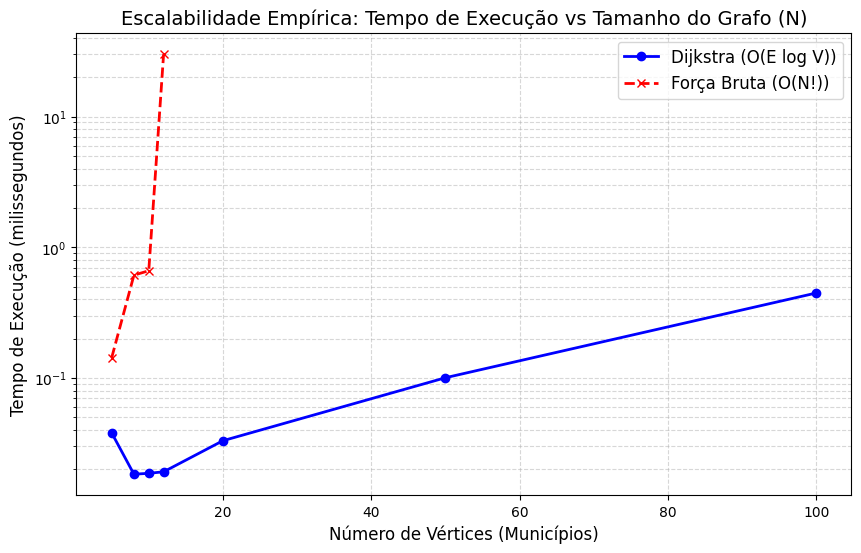

In [101]:
def gerar_grafo_aleatorio(n_vertices: int, probabilidade_aresta: float = 0.4) -> Dict[int, List[Tuple[int, float]]]:
    grafo_nx = nx.erdos_renyi_graph(n_vertices, probabilidade_aresta, seed=42, directed=False)
    if not nx.is_connected(grafo_nx):
        grafo_nx = nx.fast_gnp_random_graph(n_vertices, 0.8, seed=42)
        
    grafo_dict = {i: [] for i in range(n_vertices)}
    for u, v in grafo_nx.edges():
        peso = round(random.uniform(10.0, 100.0), 1)
        grafo_dict[u].append((v, peso))
        grafo_dict[v].append((u, peso))
    return grafo_dict

def run_benchmark_e_plotar(func_dijkstra: Callable, func_forca_bruta: Callable):
    tamanhos_n = [5, 8, 10, 12, 20, 50, 100]
    tempos_dijkstra = []
    tempos_fb = []
    
    print(f"{'N':<5} | {'Algoritmo':<15} | {'Tempo (ms)':<15} | {'Memória (MB)':<15}")
    print("-" * 60)
    
    for n in tamanhos_n:
        grafo = gerar_grafo_aleatorio(n)
        origem, destino = 0, n - 1
        
        # --- DIJKSTRA ---
        tracemalloc.start()
        t0 = time.perf_counter()
        _ = func_dijkstra(grafo, origem, destino)
        t1 = time.perf_counter()
        mem_dijkstra = tracemalloc.get_traced_memory()[1] / (1024 * 1024)
        tracemalloc.stop()
        
        tempo_ms_dijkstra = (t1 - t0) * 1000
        tempos_dijkstra.append(tempo_ms_dijkstra)
        print(f"{n:<5} | {'Dijkstra':<15} | {tempo_ms_dijkstra:<15.4f} | {mem_dijkstra:<15.6f}")
        
        # --- FORÇA BRUTA ---
        if n <= 12:
            tracemalloc.start()
            t0 = time.perf_counter()
            _ = func_forca_bruta(grafo, origem, destino) 
            t1 = time.perf_counter()
            mem_fb = tracemalloc.get_traced_memory()[1] / (1024 * 1024) 
            tracemalloc.stop()
            
            tempo_ms_fb = (t1 - t0) * 1000
            tempos_fb.append(tempo_ms_fb)
            print(f"{n:<5} | {'Força Bruta':<15} | {tempo_ms_fb:<15.4f} | {mem_fb:<15.6f}")
        else:
            tempos_fb.append(None) 
            print(f"{n:<5} | {'Força Bruta':<15} | {'TIMEOUT (>12)':<15} | {'-':<15}")
            
    # --- GRÁFICO COMPARATIVO ---
    plt.figure(figsize=(10, 6))
    plt.plot(tamanhos_n, tempos_dijkstra, marker='o', color='blue', label='Dijkstra (O(E log V))', linewidth=2)
    
    n_validos_fb = [n for n in tamanhos_n if n <= 12]
    tempos_validos_fb = [t for t in tempos_fb if t is not None]
    plt.plot(n_validos_fb, tempos_validos_fb, marker='x', color='red', label='Força Bruta (O(N!))', linewidth=2, linestyle='--')
    
    plt.title("Escalabilidade Empírica: Tempo de Execução vs Tamanho do Grafo (N)", fontsize=14)
    plt.xlabel("Número de Vértices (Municípios)", fontsize=12)
    plt.ylabel("Tempo de Execução (milissegundos)", fontsize=12)
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=12)
    plt.show()

# Executa o benchmark imediatamente ao rodar a célula
run_benchmark_e_plotar(algoritmo_guloso_dijkstra, algoritmo_forca_bruta)

SISTEMA DE ROTEAMENTO E TRIAGEM AMBIENTAL - ROTA DA ÁGUA (CAATINGA)
[+] Cenário Carregado: Seca Extrema na Caatinga (Rota da Água)

[!] Municípios em Seca Crítica (Índice >= 8.0):
    -> Ouricuri (Índice Seca: 9.8)
    -> Salgueiro (Índice Seca: 8.2)

ANÁLISE DE DESEMPENHO E OTIMALIDADE
[A] GULOSO (Dijkstra): 120.0 km | Tempo: 0.0383 ms
[B] FORÇA BRUTA (DFS): 120.0 km | Tempo: 0.0299 ms

[+] Estrutura da Árvore de Triagem:


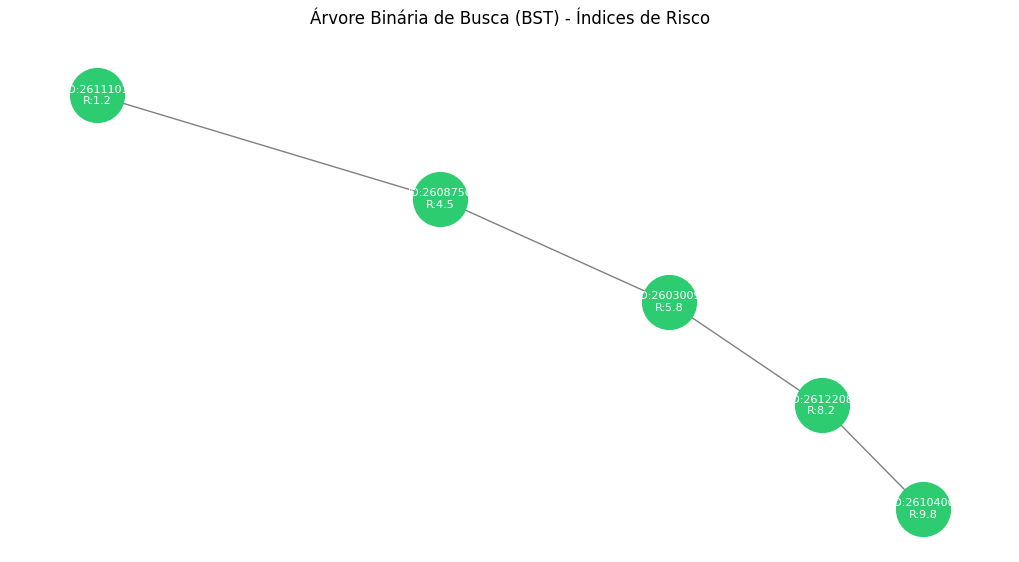


[+] Rota Selecionada na Malha Logística:


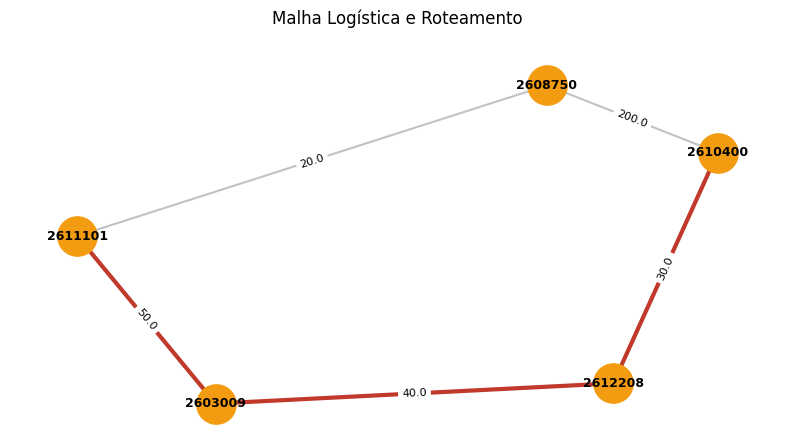


[+] Mapa Interativo da Operação:


In [102]:
print("="*70)
print("SISTEMA DE ROTEAMENTO E TRIAGEM AMBIENTAL - ROTA DA ÁGUA (CAATINGA)")
print("="*70)

# 1. Inicia o sistema
sistema_caatinga = SistemaRoteamento("caatinga") 
print(f"[+] Cenário Carregado: {sistema_caatinga.nome}")

# 2. Triagem com BST
limite_risco = 8.0
resultados_bst = sistema_caatinga.arvore_risco.buscar(limite_risco, 100.0)
resultados_bst.sort(key=lambda x: x[2], reverse=True)
fila_urgencia = deque(resultados_bst)

print(f"\n[!] Municípios em Seca Crítica (Índice >= {limite_risco}):")
for dados in fila_urgencia:
    print(f"    -> {dados[1]} (Índice Seca: {dados[2]})")

# 3. Roteamento
origem_id = 2611101  # Petrolina
destino_id = fila_urgencia[0][0] # Ouricuri (Pior índice)

t0 = time.perf_counter()
custo_guloso, rota_guloso = algoritmo_guloso_dijkstra(sistema_caatinga.grafo, origem_id, destino_id)
t_guloso = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
custo_fb, rota_fb = algoritmo_forca_bruta(sistema_caatinga.grafo, origem_id, destino_id)
t_fb = (time.perf_counter() - t0) * 1000

print("\n" + "="*70)
print(f"ANÁLISE DE DESEMPENHO E OTIMALIDADE")
print("="*70)
print(f"[A] GULOSO (Dijkstra): {custo_guloso} km | Tempo: {t_guloso:.4f} ms")
print(f"[B] FORÇA BRUTA (DFS): {custo_fb} km | Tempo: {t_fb:.4f} ms")

# 4. Plots Estáticos
print("\n[+] Estrutura da Árvore de Triagem:")
plot_bst(sistema_caatinga.arvore_risco)

print("\n[+] Rota Selecionada na Malha Logística:")
plot_grafo_estatico(sistema_caatinga.grafo, caminho_destaque=rota_fb)

# 5. Geração e Exibição Imediata do Mapa Interativo
print("\n[+] Mapa Interativo da Operação:")
mapa_caatinga = gerar_mapa_folium(rota_fb, sistema_caatinga.coords, arquivo="mapa_operacao_caatinga.html")

# Renderiza o mapa da Amazônia logo abaixo dos gráficos estáticos
display(mapa_caatinga)

SISTEMA DE ROTEAMENTO E TRIAGEM AMBIENTAL - AMAZÔNIA
[+] Cenário Carregado: Rotas de Fiscalização (DETER/Amazônia)

[!] Municípios em Risco Crítico (Desmatamento >= 8.0):
    -> São Félix do Xingu (Taxa: 9.5)
    -> Altamira (Taxa: 8.9)

RESULTADO DO ROTEAMENTO GULOSO
Caminho: Manaus (Base Central) -> Altamira -> Novo Progresso -> São Félix do Xingu
Custo Logístico Total: 85.0 (horas/km)

[+] Estrutura da Árvore de Triagem (Amazônia):


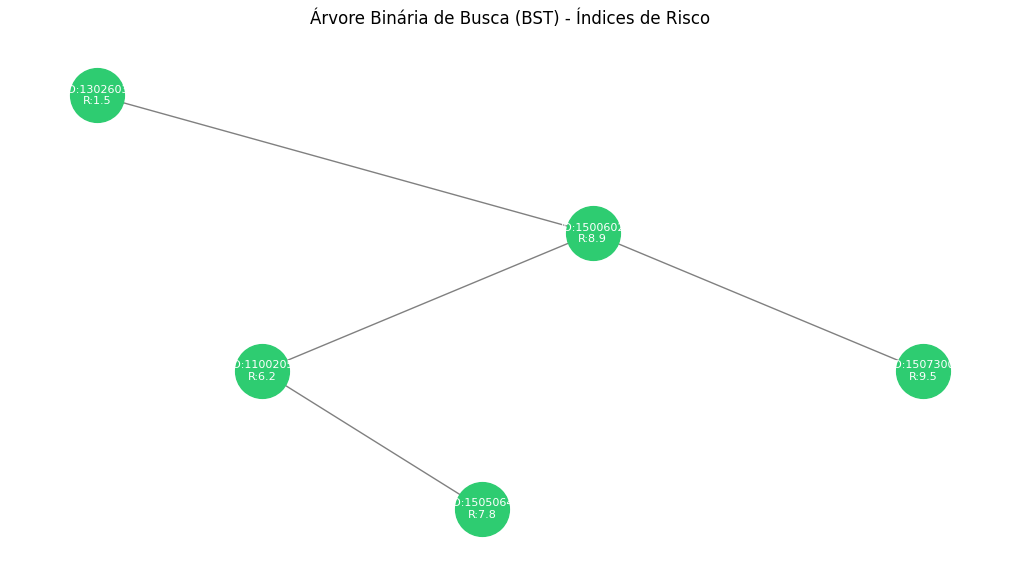


[+] Rota Selecionada na Rede de Hidrovias/Rodovias:


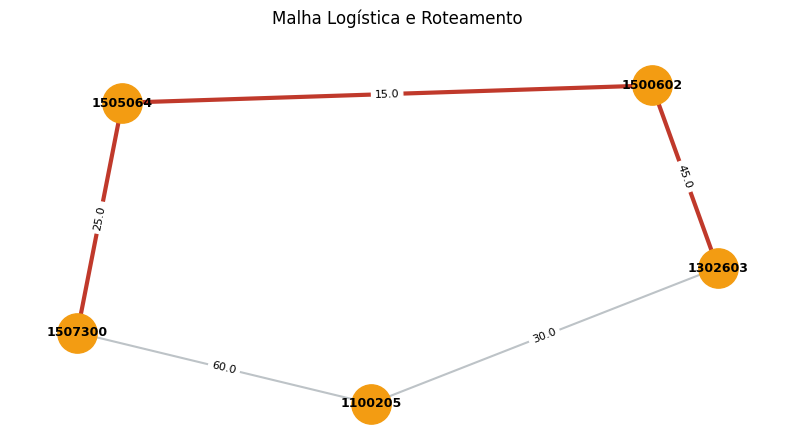


[+] Mapa Interativo da Operação:


In [103]:
print("="*60)
print("SISTEMA DE ROTEAMENTO E TRIAGEM AMBIENTAL - AMAZÔNIA")
print("="*60)

# 1. Inicia o sistema
sistema_amazonia = SistemaRoteamento("amazonia")
print(f"[+] Cenário Carregado: {sistema_amazonia.nome}")

# 2. Triagem com BST
limite_risco_am = 8.0
resultados_am = sistema_amazonia.arvore_risco.buscar(limite_risco_am, 100.0)
resultados_am.sort(key=lambda x: x[2], reverse=True)
fila_urgencia_am = deque(resultados_am)

print(f"\n[!] Municípios em Risco Crítico (Desmatamento >= {limite_risco_am}):")
for cidade in fila_urgencia_am:
    print(f"    -> {cidade[1]} (Taxa: {cidade[2]})")

# 3. Roteamento (Manaus -> Cidade de Maior Alerta)
origem_id_am = 1302603  # Manaus
destino_id_am = fila_urgencia_am[0][0] 

custo_am, rota_am = algoritmo_guloso_dijkstra(sistema_amazonia.grafo, origem_id_am, destino_id_am)
rota_nomes_am = [sistema_amazonia.municipios[node][1] for node in rota_am]

print("\n" + "="*60)
print(f"RESULTADO DO ROTEAMENTO GULOSO")
print("="*60)
print(f"Caminho: {' -> '.join(rota_nomes_am)}")
print(f"Custo Logístico Total: {custo_am} (horas/km)")

# 4. Plots Estáticos
print("\n[+] Estrutura da Árvore de Triagem (Amazônia):")
plot_bst(sistema_amazonia.arvore_risco)

print("\n[+] Rota Selecionada na Rede de Hidrovias/Rodovias:")
plot_grafo_estatico(sistema_amazonia.grafo, caminho_destaque=rota_am)

# 5. Geração e Exibição Imediata do Mapa Interativo
print("\n[+] Mapa Interativo da Operação:")
mapa_amazonia = gerar_mapa_folium(rota_am, sistema_amazonia.coords, arquivo="mapa_operacao_amazonia.html")

# Renderiza o mapa da Amazônia logo abaixo dos gráficos estáticos
display(mapa_amazonia)